# PART A

**DOMAIN:** Digital content and entertainment industry

**CONTEXT:** The objective of this project is to build a text classification model that analyses the customer's sentiments based on their reviews in the IMDB database. The model uses a complex deep learning model to build an embedding layer followed by a classification algorithm to analyse the sentiment of the customers.

**DATA DESCRIPTION:** The Dataset of 50,000 movie reviews from IMDB, labelled by sentiment (positive/negative). Reviews have been preprocessed, and each review is encoded as a sequence of word indexes (integers). For convenience, the words are indexed by their frequency in the dataset, meaning the for that has index 1 is the most frequent word. Use the first 20 words from each review to speed up training, using a max vocabulary size of 10,000. As a convention, "0" does not stand for a specific word, but instead is used to encode any unknown word.

**PROJECT OBJECTIVE:** To Build a sequential NLP classifier which can use input text parameters to determine the
customer sentiments.

In [1]:
from zipfile import ZipFile

import numpy as np
import matplotlib.pyplot as plt
import os

# pandas to open data files & processing it.
import pandas as pd
# to see all columns
pd.set_option('display.max_columns', None)
# To see whole text
pd.set_option('max_colwidth', None)

import logging
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# keras for deep learning model creation
from keras.preprocessing.text import Tokenizer

import re
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split

from keras.utils import to_categorical
from keras import models
from keras import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Flatten, TimeDistributed, Bidirectional

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import drive
drive.mount('/content/grive')

Mounted at /content/grive


In [3]:
%cd /content/grive/MyDrive/NLP_Project2/

/content/grive/MyDrive/NLP_Project2


In [4]:
# PART A
# 1. Import and analyse the data set.
from keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 [==============================] - 1s 0us/step


In [5]:
type(X_train), type(y_train)

(numpy.ndarray, numpy.ndarray)

In [6]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [7]:
#consolidating data for EDA
data = np.concatenate((X_train, X_test), axis=0)
label = np.concatenate((y_train, y_test), axis=0)

In [8]:
# PART A
# 2. Perform relevant sequence adding on the data. [5 Marks]
# Length of sequences in Data
length = [len(i) for i in data]
print("Average review length: {}".format(np.mean(length)))
print("Standard deviation: {}".format(round(np.std(length))))
print("No of reviews with length below 301: {}".format(sum(i < 301 for i in length)))

Average review length: 234.75892
Standard deviation: 173
No of reviews with length below 301: 38583


In [9]:
# Padding sequences to length of sentences equal
data_padded = pad_sequences(data, padding='post', maxlen=300)

In [10]:
# PART A
# 3. Perform following data analysis
# Print shape of features and labels
# Print value of any one feature and it's label
print('Number of reviews: {}, Number of words in each review: {}'.format(data_padded.shape[0], data_padded.shape[1]))

Number of reviews: 50000, Number of words in each review: 300


In [11]:
data_padded.size, label.size

(15000000, 50000)

In [12]:
data_padded[0]

array([   1,   14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458,
       4468,   66, 3941,    4,  173,   36,  256,    5,   25,  100,   43,
        838,  112,   50,  670,    2,    9,   35,  480,  284,    5,  150,
          4,  172,  112,  167,    2,  336,  385,   39,    4,  172, 4536,
       1111,   17,  546,   38,   13,  447,    4,  192,   50,   16,    6,
        147, 2025,   19,   14,   22,    4, 1920, 4613,  469,    4,   22,
         71,   87,   12,   16,   43,  530,   38,   76,   15,   13, 1247,
          4,   22,   17,  515,   17,   12,   16,  626,   18,    2,    5,
         62,  386,   12,    8,  316,    8,  106,    5,    4, 2223, 5244,
         16,  480,   66, 3785,   33,    4,  130,   12,   16,   38,  619,
          5,   25,  124,   51,   36,  135,   48,   25, 1415,   33,    6,
         22,   12,  215,   28,   77,   52,    5,   14,  407,   16,   82,
          2,    8,    4,  107,  117, 5952,   15,  256,    4,    2,    7,
       3766,    5,  723,   36,   71,   43,  530,  4

In [13]:
label[0]

1

In [14]:
# PART A
# 4. Decode the feature value to get original sentence [5
index = imdb.get_word_index()
reverse_index = dict([(value, key) for (key, value) in index.items()])
decoded = " ".join( [reverse_index.get(i - 3, "#") for i in data_padded[0]] )
print(decoded)

1641221/1641221 [==============================] - 1s 0us/step
# this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert # is an amazing actor and now the same being director # father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for # and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also # to the two little boy's that played the # of norman and paul they were just brilliant children are often left out of the # list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amaz

In [15]:
# PART A
# 5. Design, train, tune and test a sequential model.
train_X, test_X, train_y, test_y = train_test_split(data_padded, label, test_size=0.20, random_state=0)

In [16]:
train_X.shape, test_X.shape

((40000, 300), (10000, 300))

In [17]:
from random import seed
seed(10)
from tensorflow.random import set_seed
set_seed(10)

In [22]:
# Embedding, LSTM Model designing & Tuning

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=100, input_length=300))

# or units=100 also gives good result though 200 value gives better performance in terms of validation accuracy
model.add(LSTM(units=200, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)) # or units=100 also gives good result though 200 value gives better results

model.add(TimeDistributed(Dense(100)))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer='adam',metrics = ['accuracy']) #categorical_crossentropy
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 100)          1000000   
                                                                 
 lstm (LSTM)                 (None, 300, 200)          240800    
                                                                 
 time_distributed (TimeDistr  (None, 300, 100)         20100     
 ibuted)                                                         
                                                                 
 flatten (Flatten)           (None, 30000)             0         
                                                                 
 dense_1 (Dense)             (None, 1)                 30001     
                                                                 
Total params: 1,290,901
Trainable params: 1,290,901
Non-trainable params: 0
______________________________________________

In [23]:
train_y.shape

(40000,)

In [24]:
type(train_y)

numpy.ndarray

In [25]:
train_y = np.array(train_y)
type(train_y), train_y.shape

(numpy.ndarray, (40000,))

In [26]:
# Model Training
history = model.fit(train_X, np.array(train_y), batch_size = 300, epochs=4, validation_split = 0.1, verbose=1)

Epoch 1/4
120/120 [==============================] - 854s 7s/step - loss: 0.4240 - accuracy: 0.7872 - val_loss: 0.2698 - val_accuracy: 0.8915
Epoch 2/4
120/120 [==============================] - 865s 7s/step - loss: 0.2264 - accuracy: 0.9096 - val_loss: 0.2709 - val_accuracy: 0.8895
Epoch 3/4
120/120 [==============================] - 864s 7s/step - loss: 0.1856 - accuracy: 0.9274 - val_loss: 0.2990 - val_accuracy: 0.8857
Epoch 4/4
120/120 [==============================] - 846s 7s/step - loss: 0.1643 - accuracy: 0.9362 - val_loss: 0.3244 - val_accuracy: 0.8668


In [27]:
# Model Performance Analysis
score,acc = model.evaluate(test_X, np.array(test_y), verbose = 2, batch_size = 300)
print("score: %.2f" % (score))
print("acc: %.2f" % (acc))

34/34 - 52s - loss: 0.3135 - accuracy: 0.8715 - 52s/epoch - 2s/step
score: 0.31
acc: 0.87


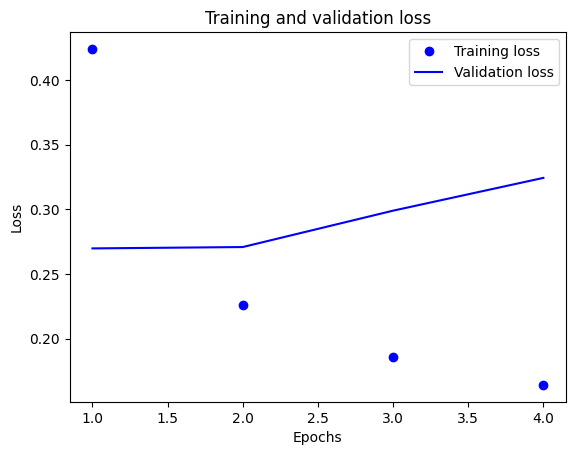

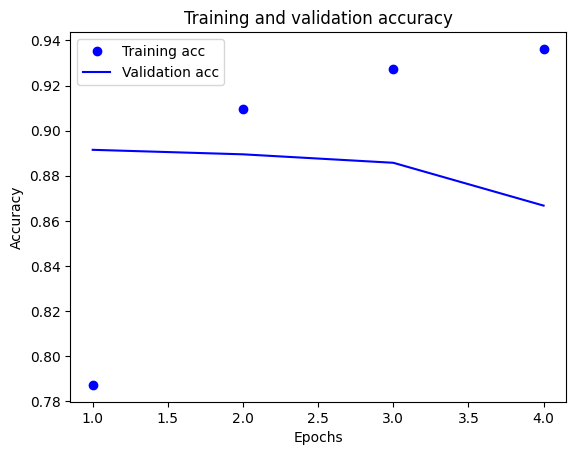

In [28]:
# Epoch Vs Accuracy & Epoch Vs Loss
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [29]:
sentiment_predicted = model.predict(test_X[10].reshape(-1,300),batch_size=1,verbose = 2)[0]
if(sentiment_predicted <= 0.5):
    print("negative")
elif(sentiment_predicted > 0.5):
    print("positive")

1/1 - 0s - 402ms/epoch - 402ms/step
negative


In [30]:
sentiment_predicted

array([0.36782676], dtype=float32)

In [31]:
# PART A
# 6. Use the designed model to print the prediction on any one sample.
index = imdb.get_word_index()
reverse_index = dict([(value, key) for (key, value) in index.items()])
test_X_decoded = " ".join( [reverse_index.get(i - 3, "#") for i in test_X[10]] )
print(test_X_decoded)

# the head of a common new york family jane # as mary barton works with her younger sister # # as # barton at # candy store after ms # is # by dealers in the buying and selling of women as # slaves ms # and her policeman boyfriend matt moore as larry burke must rescue the virtue threatened young woman br br traffic in souls has a reputation that is difficult to support it isn't remarkably well done and it doesn't show anything very unique in having a young woman's virtue threatened by sex # perhaps it can be supported as a film which dealt with the topic in a greater than # length claimed to have been ten # originally the new york city location scenes are the main attraction after all these years the # of the prisoners behind bars is memorable because nothing else seems able to make the cameras move br br traffic in souls 11 24 13 george # tucker jane # matt moore # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #

# PART B

**DOMAIN:** Social media analytics

**CONTEXT:** Past studies in Sarcasm Detection mostly make use of Twitter datasets collected using hashtag based supervision but such datasets are noisy in terms of labels and language. Furthermore, many tweets are replies to
other tweets and detecting sarcasm in these requires the availability of contextual tweets.In this hands-on project, the goal is to build a model to detect whether a sentence is sarcastic or not, using Bidirectional LSTMs.

**DATA DESCRIPTION:**
The dataset is collected from two news websites, theonion.com and huffingtonpost.com.
This new dataset has the following advantages over the existing Twitter datasets:
Since news headlines are written by professionals in a formal manner, there are no spelling mistakes and informal usage. This
reduces the sparsity and also increases the chance of finding pre-trained embeddings.
Furthermore, since the sole purpose of TheOnion is to publish sarcastic news, we get high-quality labels with much less noise as
compared to Twitter datasets.
Unlike tweets that reply to other tweets, the news headlines obtained are self-contained. This would help us in teasing apart the
real sarcastic elements
Content: Each record consists of three attributes:
is_sarcastic: 1 if the record is sarcastic otherwise 0
headline: the headline of the news article
article_link: link to the original news article. Useful in collecting supplementary data

**Reference:** https://github.com/rishabhmisra/News-Headlines-Dataset-For-Sarcasm-Detection

**PROJECT OBJECTIVE:** Build a sequential NLP classifier which can use input text parameters to determine the
customer sentiments.

In [20]:
from zipfile import ZipFile

import numpy as np
import matplotlib.pyplot as plt
import os

# pandas to open data files & processing it.
import pandas as pd
# to see all columns
pd.set_option('display.max_columns', None)
# To see whole text
pd.set_option('max_colwidth', None)

import logging
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# keras for deep learning model creation
from keras.preprocessing.text import Tokenizer
from keras.preprocessing import text, sequence

import keras
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM,Dropout,Bidirectional,GRU
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
from keras.utils import pad_sequences

from keras.utils import to_categorical
from keras import models
from keras import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Dropout, Flatten, TimeDistributed, Bidirectional, GRU

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from google.colab import drive
drive.mount('/content/grive')

Drive already mounted at /content/grive; to attempt to forcibly remount, call drive.mount("/content/grive", force_remount=True).


In [4]:
%cd /content/grive/MyDrive/NLP_Project2/

/content/grive/MyDrive/NLP_Project2


In [5]:
# PART B
# 1. Read and explore the data
data = pd.read_json('Sarcasm_Headlines_Dataset.json', lines = True)
data.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clock of hair loss,https://www.theonion.com/thirtysomething-scientists-unveil-doomsday-clock-of-hai-1819586205
1,0,"dem rep. totally nails why congress is falling short on gender, racial equality",https://www.huffingtonpost.com/entry/donna-edwards-inequality_us_57455f7fe4b055bb1170b207
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-veggies-9-delici_b_8899742.html
3,1,inclement weather prevents liar from getting to work,https://local.theonion.com/inclement-weather-prevents-liar-from-getting-to-work-1819576031
4,1,mother comes pretty close to using word 'streaming' correctly,https://www.theonion.com/mother-comes-pretty-close-to-using-word-streaming-cor-1819575546


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [9]:
data.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

In [10]:
data.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clock of hair loss,https://www.theonion.com/thirtysomething-scientists-unveil-doomsday-clock-of-hai-1819586205
1,0,"dem rep. totally nails why congress is falling short on gender, racial equality",https://www.huffingtonpost.com/entry/donna-edwards-inequality_us_57455f7fe4b055bb1170b207
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-veggies-9-delici_b_8899742.html
3,1,inclement weather prevents liar from getting to work,https://local.theonion.com/inclement-weather-prevents-liar-from-getting-to-work-1819576031
4,1,mother comes pretty close to using word 'streaming' correctly,https://www.theonion.com/mother-comes-pretty-close-to-using-word-streaming-cor-1819575546


In [11]:
df_sarcastic = data.is_sarcastic.value_counts().to_frame()
df_sarcastic

,is_sarcastic
0,14985
1,13634


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

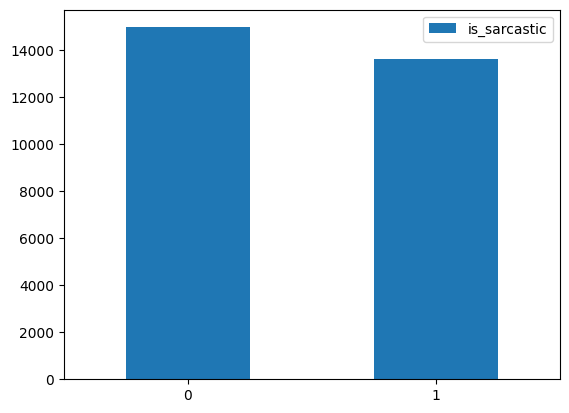

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
df_sarcastic.plot(kind = 'bar')
plt.xticks(rotation = 0)

In [13]:
# PART B
# 2. Retain relevant columns
# Drop unwanted column
data = data.drop(columns = 'article_link', axis = 1)
data.head()

,is_sarcastic,headline
0,1,thirtysomething scientists unveil doomsday clock of hair loss
1,0,"dem rep. totally nails why congress is falling short on gender, racial equality"
2,0,eat your veggies: 9 deliciously different recipes
3,1,inclement weather prevents liar from getting to work
4,1,mother comes pretty close to using word 'streaming' correctly


In [14]:
data.dtypes

is_sarcastic     int64
headline        object
dtype: object

In [15]:
data['headline'].duplicated().sum()

116

In [16]:
# Remove duplicates
data.duplicated().sum()

116

In [17]:
data[data['headline'].duplicated(keep=False)]

,is_sarcastic,headline
53,1,report: make it stop
360,1,if area dad steps on legos one more time
489,0,sunday roundup
646,0,hillary clinton vs. herself
899,1,visit home reveals parents currently watching previously undiscovered game show
...,...,...
28235,1,magical gallery transforms dull objects into art
28246,1,candy purchase puts yet more money in raisinets' bloated coffers
28449,1,congress raises killing age to 19
28456,1,rotating knife vortex closed pending safety investigation


In [18]:
data = data.drop_duplicates()
print(data.shape)

(28503, 2)


In [21]:
def split_into_words(text):
  # split into words by white space
  words = text.split()
  return words

log = logging.getLogger(__name__)
log.addHandler(logging.NullHandler())

def lowercase(words_list):
  logging.info("Converting list of words to lowercase")
  lowercase = []
  for word in words_list:
    lowercase.append(word.lower())
  return lowercase

def remove_special_characters(words_list):
  log.info("Removing special characters from array of words")
  #no_special_characters = df.replace(r'[^A-Za-z]+',' ', regex=True)
  no_special_characters = [re.sub('[^a-zA-Z0-9]+', '', _) for _ in words_list]
  return no_special_characters

def remove_url(words_str):
  return re.sub('http\S+','', words_str)

stops = set(stopwords.words('english'))

def remove_stopwords(words_str):
  stopwords_removed = " ".join([word for word in words_str.split() if word not in (stops)])
  return stopwords_removed

def remove_whitespace(words_str):
  log.info("Removing extra whitespaces between words")
  # replace more than 1 space with 1 space
  merged_spaces = words_str.replace(r"\s\s+",' ')
  # delete beginning and trailing spaces
  trimmed_spaces = merged_spaces.strip()
  return trimmed_spaces

def to_sentence(words):
  # join words to a sentence
  return ' '.join(words)

def denoise(text):
  words_list = split_into_words(text)
  words_list = lowercase(words_list)
  words_list = remove_special_characters(words_list)
  words_str = to_sentence(words_list)
  words_str = remove_url(words_str)
  words_str = remove_stopwords(words_str)
  words_str = remove_whitespace(words_str)
  return words_str


data['cleaned_headline'] = data['headline'].apply(denoise)

In [22]:
data['cleaned_headline'].head()

0             thirtysomething scientists unveil doomsday clock hair loss
1    dem rep totally nails congress falling short gender racial equality
2                            eat veggies 9 deliciously different recipes
3                           inclement weather prevents liar getting work
4               mother comes pretty close using word streaming correctly
Name: cleaned_headline, dtype: object

In [23]:
len(data['cleaned_headline'][7].split())

10

In [24]:
# PART B
# 3. Get length of each sentence
len_sentences = [len(i) for i in data['cleaned_headline']]
print("Length of each sentence in the dataframe", len_sentences)

Length of each sentence in the dataframe [58, 67, 43, 44, 56, 17, 29, 77, 63, 26, 45, 41, 39, 89, 42, 65, 54, 25, 32, 50, 62, 62, 8, 33, 60, 48, 29, 31, 63, 35, 33, 21, 23, 82, 57, 41, 82, 44, 71, 46, 26, 60, 46, 62, 61, 56, 38, 55, 56, 44, 59, 45, 64, 16, 82, 52, 60, 34, 68, 42, 84, 33, 26, 66, 45, 76, 42, 43, 68, 62, 21, 43, 66, 38, 81, 73, 38, 25, 19, 72, 63, 72, 74, 59, 57, 54, 45, 68, 60, 70, 47, 53, 17, 66, 40, 47, 100, 63, 54, 36, 65, 41, 57, 66, 31, 92, 45, 42, 57, 43, 38, 62, 41, 41, 50, 50, 31, 67, 69, 43, 51, 29, 46, 21, 53, 59, 51, 52, 52, 46, 73, 36, 50, 57, 42, 85, 64, 62, 58, 34, 51, 47, 37, 60, 88, 65, 58, 52, 40, 41, 23, 75, 44, 66, 59, 68, 43, 73, 49, 31, 33, 25, 59, 50, 56, 34, 29, 60, 38, 49, 44, 68, 8, 35, 49, 16, 59, 72, 53, 65, 34, 39, 91, 113, 64, 45, 84, 32, 88, 25, 49, 71, 56, 15, 61, 83, 53, 47, 67, 69, 48, 43, 59, 61, 54, 31, 65, 42, 60, 28, 74, 57, 35, 79, 41, 45, 36, 22, 31, 24, 54, 44, 36, 49, 43, 24, 83, 43, 46, 25, 39, 47, 63, 59, 50, 56, 43, 96, 34, 49

In [61]:
print("Max review length in the dataset: {}".format(max(len_sentences)))
print("Average review length: {}".format(np.mean(len_sentences)))
print("Standard deviation: {}".format(round(np.std(len_sentences))))
print("No of headlines with length below 67: {}".format(sum(i < 67 for i in len_sentences)))

Max review length in the dataset: 721
Average review length: 50.63077570782023
Standard deviation: 18
No of headlines with length below 67: 23662


In [63]:
y = data['is_sarcastic']
X_train, X_test,y_train, y_test = train_test_split(data['cleaned_headline'], y, test_size=0.15, random_state = 42)

In [64]:
# PART B
# 4. Define parameters
max_length = max([len(headline.split()) for headline in data['cleaned_headline']])
print('Maximum Length: ', max_length)
max_features = 10000
maxlen = max_length #39 in this case
embedding_size = 200


Maximum Length:  106


In [65]:
words = []
for i in data.headline.values:
    words.append(i.split())
words[:5]

[['thirtysomething',
  'scientists',
  'unveil',
  'doomsday',
  'clock',
  'of',
  'hair',
  'loss'],
 ['dem',
  'rep.',
  'totally',
  'nails',
  'why',
  'congress',
  'is',
  'falling',
  'short',
  'on',
  'gender,',
  'racial',
  'equality'],
 ['eat', 'your', 'veggies:', '9', 'deliciously', 'different', 'recipes'],
 ['inclement', 'weather', 'prevents', 'liar', 'from', 'getting', 'to', 'work'],
 ['mother',
  'comes',
  'pretty',
  'close',
  'to',
  'using',
  'word',
  "'streaming'",
  'correctly']]

In [66]:
import gensim
#Dimension of vectors we are generating
EMBEDDING_DIM = 200

#Creating Word Vectors by Word2Vec Method (takes time...)
w2v_model = gensim.models.Word2Vec(sentences = words, window = 5 , min_count = 1)

In [67]:
# PART B
# 5. Get indices for words
# Fitting a basic tokenizer on the dataset to arrive at the desired vocabulary
tokenizer = Tokenizer() # oov_token='<OOV>'
tokenizer.fit_on_texts(list(data['cleaned_headline']))

In [68]:
# Frequency of each word in the word_index list of tokenizer

word_count = tokenizer.word_counts

# sort them out

sorted_word_count = sorted(word_count.items(), key=lambda x:x[1])
print(sorted_word_count)

[('thirtysomething', 1), ('deliciously', 1), ('bransons', 1), ('marriott', 1), ('harams', 1), ('jumpingandtouchingtopsofdoorways', 1), ('hallway', 1), ('110', 1), ('grier', 1), ('lamelo', 1), ('gunfight', 1), ('probability', 1), ('shoesharing', 1), ('sculpted', 1), ('alluring', 1), ('entomology', 1), ('upn', 1), ('trumpstyle', 1), ('handshake', 1), ('velocity', 1), ('clippings', 1), ('coed', 1), ('hypercompetitive', 1), ('brutalist', 1), ('rudolphinspired', 1), ('windmill', 1), ('gaselectric', 1), ('sparkle', 1), ('libslavesinfo', 1), ('wideawakepatriotcom', 1), ('extinguishes', 1), ('fivealarm', 1), ('sheep', 1), ('gyllenhaals', 1), ('consultants', 1), ('oilman', 1), ('sleaterkinney', 1), ('barring', 1), ('publick', 1), ('cementing', 1), ('nationstate', 1), ('trademark', 1), ('jindals', 1), ('benefited', 1), ('instances', 1), ('chemists', 1), ('nano', 1), ('snakebite', 1), ('vespa', 1), ('smithereens', 1), ('dinizio', 1), ('doodles', 1), ('scattering', 1), ('goodfellas', 1), ('fragmen

In [69]:
word_count_keys =[]
word_count_keys = [key for key, val in word_count.items() if val == 1]
print('List of words from word_index of tokenizer where value/index is equal to 1 :\n\n', word_count_keys)
print('\n Size of the above list :',len(word_count_keys))

List of words from word_index of tokenizer where value/index is equal to 1 :

 ['thirtysomething', 'deliciously', 'bransons', 'marriott', 'harams', 'jumpingandtouchingtopsofdoorways', 'hallway', '110', 'grier', 'lamelo', 'gunfight', 'probability', 'shoesharing', 'sculpted', 'alluring', 'entomology', 'upn', 'trumpstyle', 'handshake', 'velocity', 'clippings', 'coed', 'hypercompetitive', 'brutalist', 'rudolphinspired', 'windmill', 'gaselectric', 'sparkle', 'libslavesinfo', 'wideawakepatriotcom', 'extinguishes', 'fivealarm', 'sheep', 'gyllenhaals', 'consultants', 'oilman', 'sleaterkinney', 'barring', 'publick', 'cementing', 'nationstate', 'trademark', 'jindals', 'benefited', 'instances', 'chemists', 'nano', 'snakebite', 'vespa', 'smithereens', 'dinizio', 'doodles', 'scattering', 'goodfellas', 'fragments', 'locates', '6000mile', 'cocksucker', 'wheelchairbound', 'preferred', 'cnncom', 'tsarnaevs', 'castros', '47second', 'covert', 'mech', 'bends', 'asu', 'gsv', 'bluecollar', 'additives', 'dig

In [70]:
# PART B
# 6. Create features and labels
X = tokenizer.texts_to_sequences(data['cleaned_headline'])
X = pad_sequences(X, maxlen = maxlen)
y = np.asarray(data['is_sarcastic'])

print("shape of x", X.shape)
print("shape of y", y.shape)


print("Number of Samples:", len(X))
print(X)
print("Number of Labels: ", len(y))
print(y)

shape of x (28503, 106)
shape of y (28503,)
Number of Samples: 28503
[[    0     0     0 ...  2200   567  1029]
 [    0     0     0 ...  1542  1983  1612]
 [    0     0     0 ... 15362   502  1336]
 ...
 [    0     0     0 ...  1004   636  1764]
 [    0     0     0 ... 29498   741  6062]
 [    0     0     0 ...  3102   182    96]]
Number of Labels:  28503
[1 0 0 ... 0 1 1]


In [71]:
# PART B
# 7. Get vocabulary size
initial_vocab_size = len(tokenizer.word_index)
print('Actual unique words/vocabulary as per the tokenizer :', initial_vocab_size)

new_vocab_size = initial_vocab_size - (len(word_count_keys))
print ('\n New vocabulary size considered till further processing :', new_vocab_size)

Actual unique words/vocabulary as per the tokenizer : 29498

 New vocabulary size considered till further processing : 15360


In [72]:
# total unique words we are going to use.
MAX_FEATURES = 14505 # same as New temp vocabulary size

# max number of words one sentence can have
MAX_LEN = 66 # 50

# width of of 1D embedding vector
EMBEDDING_SIZE = 300

In [74]:
# Creating new Tokenizer to tokenize with dataset words with Out Of Vocabulary words (size = 13746) marked '<OOV>'

num_words = MAX_FEATURES
new_tokenizer = Tokenizer(oov_token='<OOV>', num_words = MAX_FEATURES+1)
new_tokenizer.fit_on_texts(list(data['cleaned_headline']))
print ('New Tokenized Word Index', new_tokenizer.word_index)

new_tokenizer.word_index = {e:i for e,i in new_tokenizer.word_index.items() if i <= num_words} # <= because tokenizer is 1 indexed
new_tokenizer.word_index[new_tokenizer.oov_token] = num_words + 1
print('\nNew Tokenized Word Index with corrected indexing :', new_tokenizer.word_index)

New Tokenized Word Index {'<OOV>': 1, 'new': 2, 'trump': 3, 'man': 4, 'report': 5, 'us': 6, 'one': 7, 'woman': 8, 'area': 9, 'donald': 10, 'says': 11, 'day': 12, 'time': 13, 'like': 14, 'first': 15, 'get': 16, 'trumps': 17, 'people': 18, 'house': 19, 'life': 20, 'still': 21, 'white': 22, 'obama': 23, 'make': 24, 'back': 25, 'women': 26, 'could': 27, 'clinton': 28, 'years': 29, 'world': 30, 'family': 31, 'americans': 32, 'study': 33, 'way': 34, 'would': 35, 'black': 36, 'gop': 37, 'bill': 38, '5': 39, 'finds': 40, 'really': 41, 'american': 42, 'know': 43, 'police': 44, 'school': 45, 'cant': 46, 'best': 47, 'going': 48, 'watch': 49, 'good': 50, 'show': 51, 'nation': 52, 'president': 53, 'death': 54, 'home': 55, 'video': 56, 'state': 57, 'every': 58, 'things': 59, 'say': 60, 'last': 61, 'big': 62, 'love': 63, 'campaign': 64, 'mom': 65, 'year': 66, 'parents': 67, 'health': 68, 'getting': 69, 'may': 70, 'kids': 71, 'hillary': 72, 'work': 73, 'gets': 74, 'little': 75, 'party': 76, 'need': 77

In [75]:
# Tokenized word indices

list_indices_word = new_tokenizer.word_index.values() # (or) tokenizer.word_index.values()
list_indices_word

dict_values([14506, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 2

In [76]:
# Feature Values Created

cleaned_tokenized_headline_X_train = new_tokenizer.texts_to_sequences(X_train)
cleaned_tokenized_headline_X_test = new_tokenizer.texts_to_sequences(X_test)

cleaned_tokenized_headline_X_train

[[53, 3, 455, 4068, 94],
 [2879, 2040, 1272, 5473, 3, 288, 1646, 9193, 14, 2412, 6467, 1969],
 [11351, 137, 45, 745, 292],
 [2804, 7544, 2473, 395, 973, 1957, 1776, 3587],
 [754, 5541, 294, 236, 15, 13, 1769],
 [11112, 1732, 5644, 14506, 659, 52, 5697, 273, 1287, 1731, 2367],
 [244, 491, 47, 493, 274, 3731, 334, 345],
 [170, 4841, 2563, 5371],
 [1141, 1671, 23, 1987, 14506, 3650, 64],
 [5, 3884, 1674, 646, 621, 729, 34, 1792, 97, 121, 10, 3],
 [9827, 22, 19, 2750, 4240, 101, 12478, 3668],
 [453, 2133, 5946, 3172, 5010, 8246, 84, 4193, 7904],
 [9602, 70, 1545, 2877, 2221, 3868, 352, 794],
 [530, 3690, 11831, 13763, 1218, 705],
 [143, 1681, 609, 2937, 3388, 14506, 715],
 [8040, 1934, 11034, 3709, 6022, 7987, 8718, 1465, 62, 13],
 [1794, 1327, 11, 35, 1178, 225, 14506, 14506],
 [14506, 337, 351, 2386, 1177],
 [259, 20, 609, 821, 2251, 3830],
 [5, 412, 1059, 2408, 481, 1085],
 [1684, 762, 490, 361, 24, 97, 87, 5956, 41, 1638],
 [612, 463, 2, 67, 1864, 178, 15, 13],
 [345, 3391, 2617, 390, 

In [77]:
X_train.head()

7513                                              president trump less unpopular hes
2021     stormy daniels lawyer taunts trump michael cohen fold like cheap deck cards
14517                                       navigate high school transgender student
24020                     jake gyllenhaal singing heart ahead broadway musical debut
23257                               chicago landmarks open public first time decades
Name: cleaned_headline, dtype: object

In [78]:
# Bringing sequences to the same length

X_train_padded = pad_sequences(cleaned_tokenized_headline_X_train, padding='post', maxlen = 66)
X_test_padded = pad_sequences(cleaned_tokenized_headline_X_test, padding='post', maxlen = 66)

In [79]:
# New vocabulary size post marking less frequency words as OOV_token

print('max number of unique words in the dataset / NEW vocabulary size is  :', (MAX_FEATURES +1))

max number of unique words in the dataset / NEW vocabulary size is  : 14506


In [80]:
# PART B
# 8. Create a weight matrix using GloVe embeddings
project_path = "/content/grive/MyDrive/NLP_Project2/"
glove_file = project_path + "glove.6B.zip"

In [81]:
#Extract Glove embedding zip file
from zipfile import ZipFile
with ZipFile(glove_file, 'r') as z:
  z.extractall()

In [82]:
EMBEDDING_FILE = './glove.6B.200d.txt'

embeddings = {}
for o in open(EMBEDDING_FILE):
    word = o.split(" ")[0]
    embd = o.split(" ")[1:]
    embd = np.asarray(embd, dtype='float32')
    embeddings[word] = embd

In [83]:
embedding_matrix = np.zeros((vocab_size, 200))

for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

len(embeddings.values())

400000

In [84]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.13451999,  0.42318001, -0.20051999, ..., -0.0091233 ,
         0.31496999,  0.47435999],
       [-0.80177999,  0.16873001,  0.17636   , ...,  0.70449001,
         0.46037999, -0.26025   ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [85]:
# PART B
# 9. Define and compile a Bidirectional LSTM model.
from random import seed
seed(10)
from tensorflow.random import set_seed
set_seed(10)

In [87]:
### create the model
model = Sequential()

### Embedding layer for hint
model.add(Embedding(vocab_size, embedding_size, weights = [embedding_matrix]))

### Bidirectional LSTM layer for hint
model.add(Bidirectional(LSTM(512, return_sequences = True)))

### dense
model.add(Dense(256, activation = 'relu'))

##dropout
model.add(Dropout(0.5, input_shape = (256,)))

##sigmoid
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 200)         7647000   
                                                                 
 bidirectional_2 (Bidirectio  (None, None, 1024)       2920448   
 nal)                                                            
                                                                 
 dense_4 (Dense)             (None, None, 256)         262400    
                                                                 
 dropout_2 (Dropout)         (None, None, 256)         0         
                                                                 
 dense_5 (Dense)             (None, None, 1)           257       
                                                                 
Total params: 10,830,105
Trainable params: 10,830,105
Non-trainable params: 0
__________________________________________

In [88]:
X_train_padded.shape, y_train.shape

((24227, 66), (24227,))

In [92]:
# PART B
# 10. Fit the model and check the validation accuracy
history = model.fit(X_train_padded, y_train,
                    epochs = 5,
                    batch_size=128,
                    validation_data=(X_test_padded, y_test), verbose = 2)

Epoch 1/5
190/190 - 1050s - loss: 0.6083 - accuracy: 0.6553 - val_loss: 0.5192 - val_accuracy: 0.7670 - 1050s/epoch - 6s/step
Epoch 2/5
190/190 - 1020s - loss: 0.3816 - accuracy: 0.8386 - val_loss: 0.4675 - val_accuracy: 0.7924 - 1020s/epoch - 5s/step
Epoch 3/5
190/190 - 1021s - loss: 0.2641 - accuracy: 0.8955 - val_loss: 0.4637 - val_accuracy: 0.8048 - 1021s/epoch - 5s/step
Epoch 4/5
190/190 - 1028s - loss: 0.1967 - accuracy: 0.9248 - val_loss: 0.5898 - val_accuracy: 0.7991 - 1028s/epoch - 5s/step
Epoch 5/5
190/190 - 1026s - loss: 0.1526 - accuracy: 0.9451 - val_loss: 0.5847 - val_accuracy: 0.7949 - 1026s/epoch - 5s/step


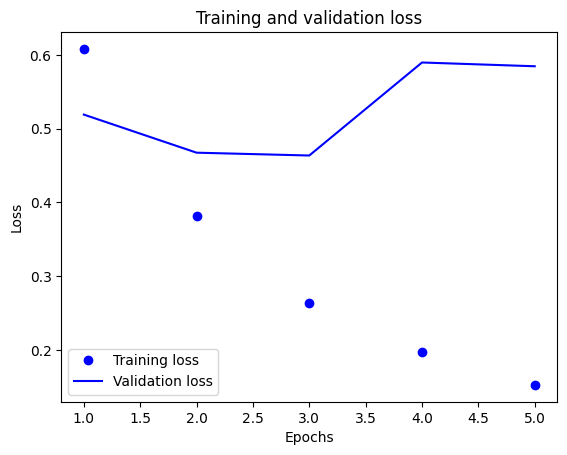

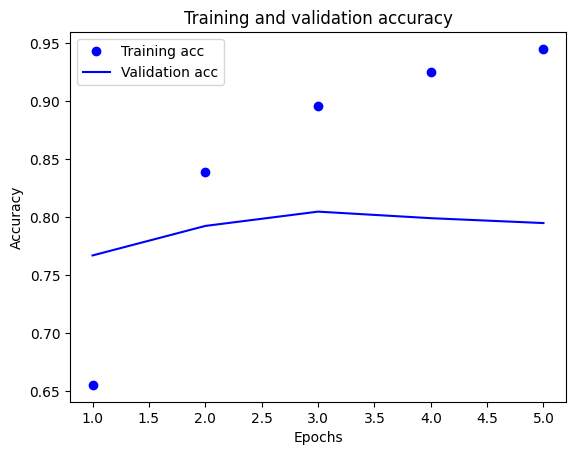

In [93]:
# Plot Epoch Vs Accuracy & Epoch Vs Loss to assess the model performance

import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [94]:
print("The count of token words/frequency of their occurrence : ",tokenizer.word_counts)

The count of token words/frequency of their occurrence :  OrderedDict([('thirtysomething', 1), ('scientists', 103), ('unveil', 13), ('doomsday', 5), ('clock', 18), ('hair', 59), ('loss', 38), ('dem', 4), ('rep', 25), ('totally', 54), ('nails', 13), ('congress', 139), ('falling', 23), ('short', 40), ('gender', 26), ('racial', 20), ('equality', 25), ('eat', 46), ('veggies', 2), ('9', 63), ('deliciously', 1), ('different', 64), ('recipes', 30), ('inclement', 2), ('weather', 27), ('prevents', 5), ('liar', 8), ('getting', 211), ('work', 201), ('mother', 84), ('comes', 79), ('pretty', 119), ('close', 42), ('using', 68), ('word', 63), ('streaming', 9), ('correctly', 5), ('white', 365), ('inheritance', 3), ('5', 257), ('ways', 129), ('file', 9), ('taxes', 16), ('less', 69), ('stress', 29), ('richard', 24), ('bransons', 1), ('globalwarming', 2), ('donation', 13), ('nearly', 39), ('much', 144), ('cost', 27), ('failed', 31), ('balloon', 12), ('trips', 9), ('shadow', 14), ('government', 116), ('la